# Análise

Esta etapa está dividida em **qualidade de dados** e **solução do problema**.

In [0]:
spark.sql("USE CATALOG MVP_gastos_publicos")
spark.sql("USE SCHEMA gold")

DataFrame[]

In [0]:
from pyspark.sql.functions import col, count, when, isnan

# Verificar se existem dados nulos (NULL) para cada coluna

df = spark.table("gastos_publicos")

null_counts = df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
])


display(null_counts)

ID_ANO,ID_MES,data_referencia,ORGAO_DESCRICAO,NO_FUNCAO_PT,NO_SUBFUNCAO_PT,NO_PROGRAMA_PT,NO_ACAO,DOTACAO_INICIAL,DOTACAO_ATUALIZADA,DESPESAS_EMPENHADAS,DESPESAS_LIQUIDADAS,DESPESAS_PAGAS,RESTOS_A_PAGAR_PAGOS,PAGAMENTOS_TOTAIS,Poder_Orgao,Primaria_Financeira
0,0,0,0,0,36,36,60,100582,91425,70597,49718,47663,67097,0,0,0


In [0]:
# Verificar se existem valores negativos nas colunas financeiras

df = spark.table("gastos_publicos")

colunas_financeiras = ['DOTACAO_INICIAL', 'DOTACAO_ATUALIZADA', 'DESPESAS_EMPENHADAS', 
                       'DESPESAS_LIQUIDADAS', 'DESPESAS_PAGAS', 'PAGAMENTOS_TOTAIS']

for coluna in colunas_financeiras:
    negativos = df.filter(col(coluna) < 0).count()
    print(f"{coluna}: {negativos} valores negativos")

DOTACAO_INICIAL: 14108 valores negativos
DOTACAO_ATUALIZADA: 23093 valores negativos
DESPESAS_EMPENHADAS: 10607 valores negativos
DESPESAS_LIQUIDADAS: 1364 valores negativos
DESPESAS_PAGAS: 1066 valores negativos
PAGAMENTOS_TOTAIS: 1925 valores negativos


In [0]:
# Verificar valores máximo e mínimo das colunas financeiras

df = spark.table("gastos_publicos")

from pyspark.sql.functions import max as spark_max, min as spark_min

extremos = df.agg(
    spark_max("PAGAMENTOS_TOTAIS").alias("max_pagamento"),
    spark_min("PAGAMENTOS_TOTAIS").alias("min_pagamento"),
    spark_max("DESPESAS_EMPENHADAS").alias("max_empenhado"),
    spark_min("DESPESAS_EMPENHADAS").alias("min_empenhado")
)

print("Valores extremos (máximo e mínimo):")
display(extremos)

Valores extremos (máximo e mínimo):


max_pagamento,min_pagamento,max_empenhado,min_empenhado
372660052070.52,-30115252072.75,431094375000.00,-56503510036.00


In [0]:
# Verificar se existem registros duplicados

df = spark.table("gastos_publicos")

total_registros = df.count()
registros_unicos = df.distinct().count()
duplicados = total_registros - registros_unicos

print(f"Total de registros: {total_registros}")
print(f"Registros únicos: {registros_unicos}")
print(f"Registros duplicados: {duplicados}")

Total de registros: 270498
Registros únicos: 266096
Registros duplicados: 4402


In [0]:
%sql
-- Verificar se todos os meses de 2024 e 2025 estão presentes

SELECT 
    ID_ANO,
    ID_MES,
    COUNT(*) as total_registros
FROM evolucao_mensal
GROUP BY ID_ANO, ID_MES
ORDER BY ID_ANO, ID_MES;

ID_ANO,ID_MES,total_registros
2024,1,1
2024,2,1
2024,3,1
2024,4,1
2024,5,1
2024,6,1
2024,7,1
2024,8,1
2024,9,1
2024,10,1


### Pronto! 
## feito todas as verificações!


#Os dados estão prontos para análise!

---
# Solução do Problema

Próximo passo: responder as 5 perguntas de negócio com análises e visualizações.

In [0]:
%sql --name top_orgaos
-- Pergunta 1: Quais órgãos tiveram os maiores gastos em 2024-2025?
SELECT 
    ORGAO_DESCRICAO,
    Poder_Orgao,
    ROUND(pagamentos_totais / 1000000000, 2) as pagamentos_bilhoes
FROM MVP_gastos_publicos.gold.gastos_por_orgao_ano
ORDER BY pagamentos_totais DESC
LIMIT 10;

ORGAO_DESCRICAO,Poder_Orgao,pagamentos_bilhoes
MINISTERIO DA FAZENDA,EXE,2778.90
MINISTERIO DA FAZENDA,EXE,2566.08
MINISTERIO DA PREVIDENCIA SOCIAL,EXE,1045.87
MINISTERIO DA PREVIDENCIA SOCIAL,EXE,953.63
"MIN.DESENV.E ASSIT.SOCIAL,FAM.E COMBATE FOME",EXE,296.29
"MIN.DESENV.E ASSIT.SOCIAL,FAM.E COMBATE FOME",EXE,289.81
MINISTERIO DA SAUDE,EXE,251.76
MINISTERIO DA EDUCACAO,EXE,230.51
MINISTERIO DA SAUDE,EXE,226.07
MINISTERIO DA EDUCACAO,EXE,198.30


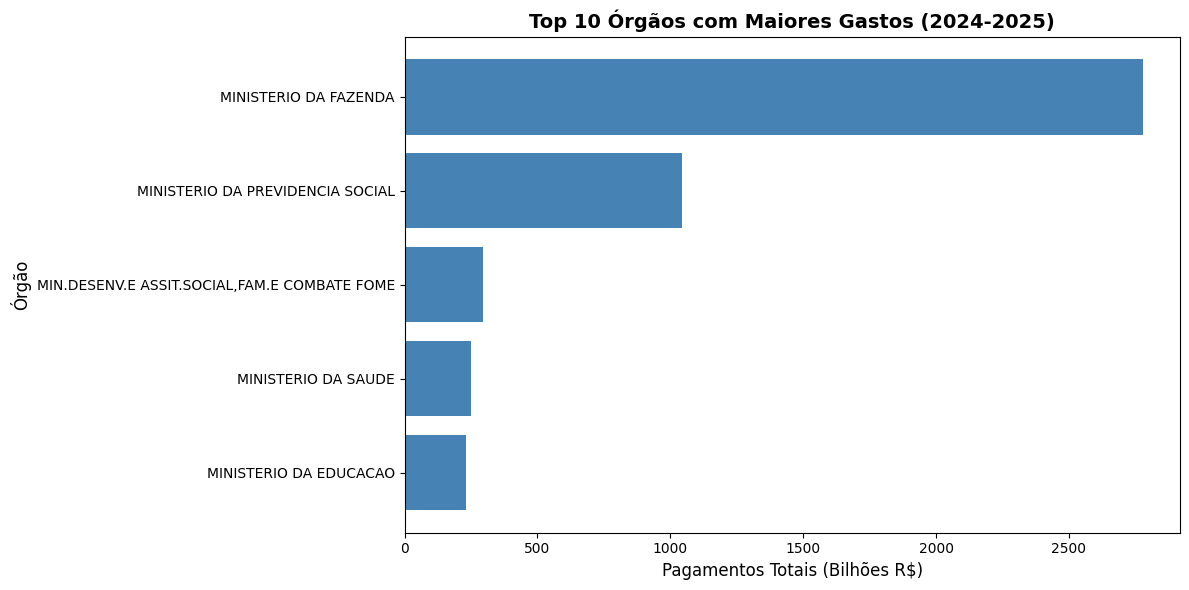


 Gráfico: Os órgãos com maiores gastos são os relacionados à Previdência Social, Saúde e Educação.


In [0]:
import matplotlib.pyplot as plt
import pandas as pd

# Converter resultado SQL para pandas
df_top_orgaos = top_orgaos.toPandas()

# Criar um gráfico de barras para melhor visualizar

plt.figure(figsize=(12, 6))
plt.barh(df_top_orgaos['ORGAO_DESCRICAO'], df_top_orgaos['pagamentos_bilhoes'], color='steelblue')
plt.xlabel('Pagamentos Totais (Bilhões R$)', fontsize=12)
plt.ylabel('Órgão', fontsize=12)
plt.title('Top 10 Órgãos com Maiores Gastos (2024-2025)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()

print("\n Gráfico: Os órgãos com maiores gastos são os relacionados à Previdência Social, Saúde e Educação.")

In [0]:
%sql --name evolucao
-- Pergunta 2: Como os gastos evoluíram mensalmente ao longo do tempo?
SELECT 
    data_referencia,
    ROUND(pagamentos_totais / 1000000000, 2) as pagamentos_bilhoes
FROM evolucao_mensal
ORDER BY data_referencia;

data_referencia,pagamentos_bilhoes
2024-01-01,658.17
2024-02-01,312.04
2024-03-01,441.11
2024-04-01,394.26
2024-05-01,321.04
2024-06-01,274.33
2024-07-01,461.22
2024-08-01,565.24
2024-09-01,500.14
2024-10-01,339.00


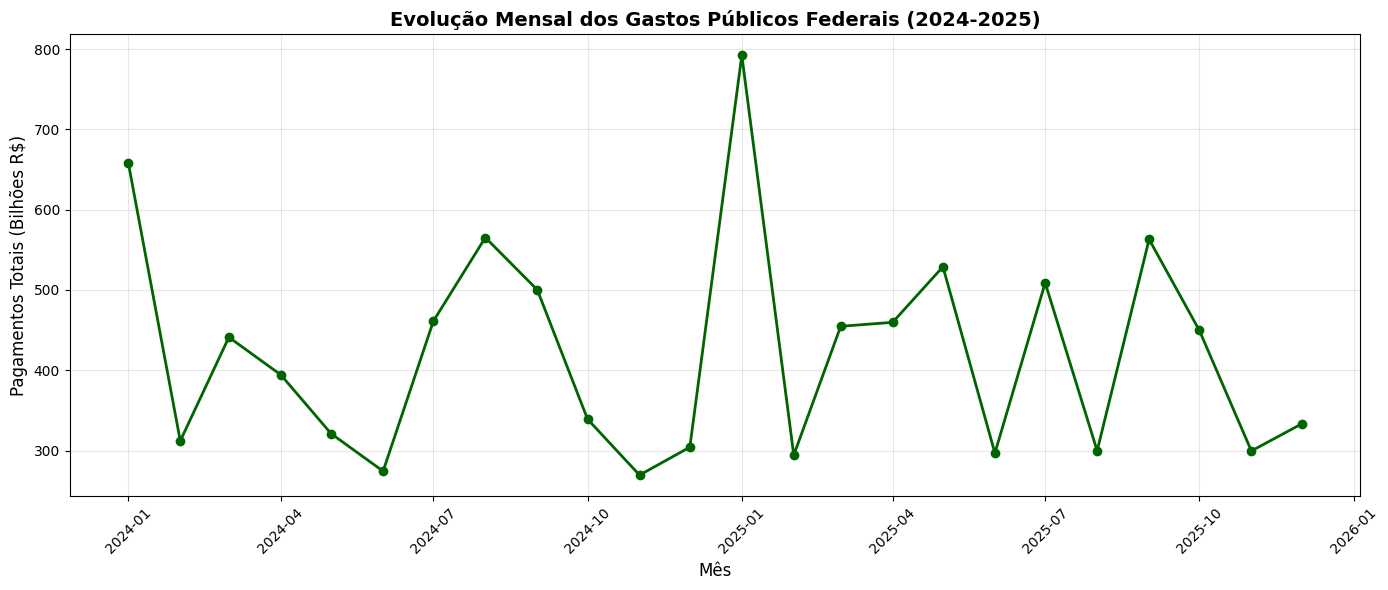


 gráfico: Os gastos apresentam sazonalidade, com picos em determinados meses do ano.


In [0]:
import matplotlib.pyplot as plt
import pandas as pd

# Converter resultado SQL para pandas
df_evolucao = evolucao.toPandas()
df_evolucao['data_referencia'] = pd.to_datetime(df_evolucao['data_referencia'])

# Agora criar gráfico de linha para visualizar melhor 
plt.figure(figsize=(14, 6))
plt.plot(df_evolucao['data_referencia'], df_evolucao['pagamentos_bilhoes'], 
         marker='o', linewidth=2, markersize=6, color='darkgreen')
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Pagamentos Totais (Bilhões R$)', fontsize=12)
plt.title('Evolução Mensal dos Gastos Públicos Federais (2024-2025)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n gráfico: Os gastos apresentam sazonalidade, com picos em determinados meses do ano.")

In [0]:
%sql 
-- Pergunta 3: Quais funções de governo (saúde, educação, defesa) recebem mais recursos?
SELECT 
    funcao,
    ROUND(SUM(pagamentos_totais) / 1000000000, 2) as pagamentos_bilhoes
FROM gastos_por_funcao
GROUP BY funcao
ORDER BY pagamentos_bilhoes DESC
LIMIT 10;

funcao,pagamentos_bilhoes
ENCARGOS ESPECIAIS,5675.22
PREVIDENCIA SOCIAL,2145.57
ASSISTENCIA SOCIAL,574.31
SAUDE,453.61
EDUCACAO,344.78
TRABALHO,230.90
DEFESA NACIONAL,193.89
JUDICIARIA,101.44
AGRICULTURA,77.90
ADMINISTRACAO,63.91


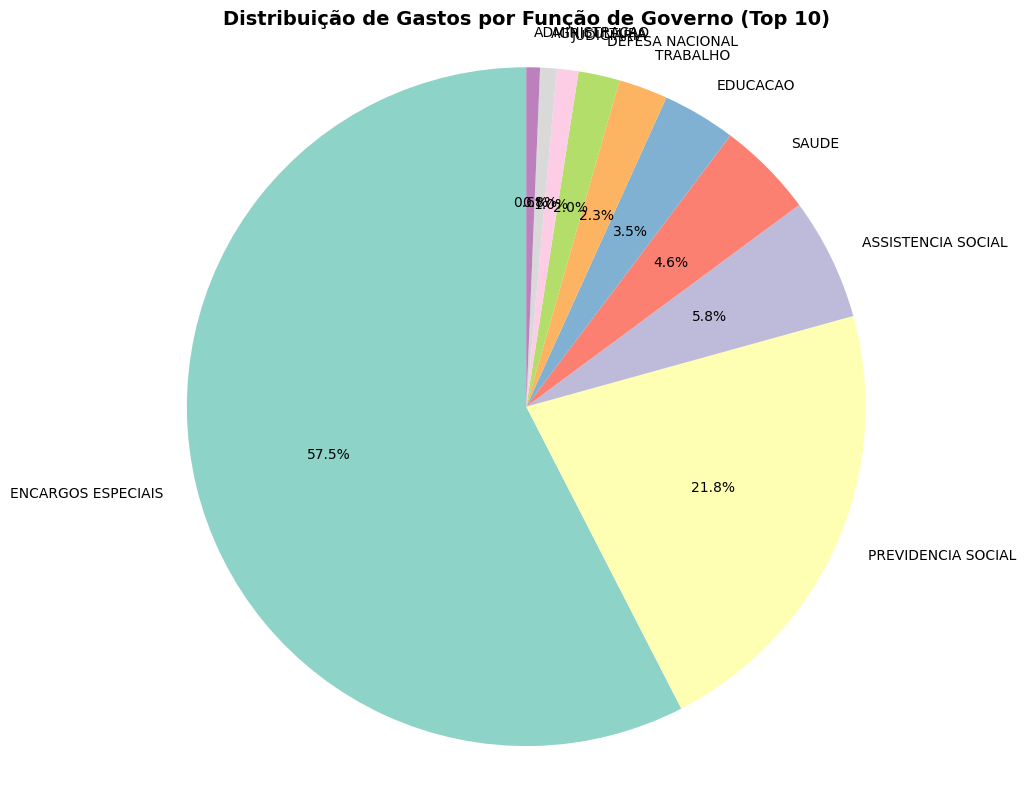


 Gráfico: Previdência Social, Saúde e Educação concentram a maior parte do orçamento federal.


In [0]:
import matplotlib.pyplot as plt
import pandas as pd

# convertendo 
df_funcoes = top_funcoes.toPandas()

# Criar gráfico de pizza
plt.figure(figsize=(10, 8))
colors = plt.cm.Set3(range(len(df_funcoes)))
plt.pie(df_funcoes['pagamentos_bilhoes'], labels=df_funcoes['funcao'], autopct='%1.1f%%',
        startangle=90, colors=colors, textprops={'fontsize': 10})
plt.title('Distribuição de Gastos por Função de Governo (Top 10)', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

print("\n Gráfico: Previdência Social, Saúde e Educação concentram a maior parte do orçamento federal.")

In [0]:
%sql --name orcado_vs_executado
-- Pergunta 4: Qual a diferença entre o orçamento previsto (dotação) e o executado (pago)?
SELECT 
    ID_ANO,
    ROUND(SUM(DOTACAO_ATUALIZADA) / 1000000000, 2) as orcado_bilhoes,
    ROUND(SUM(PAGAMENTOS_TOTAIS) / 1000000000, 2) as executado_bilhoes,
    ROUND((SUM(PAGAMENTOS_TOTAIS) / SUM(DOTACAO_ATUALIZADA)) * 100, 2) as percentual_executado
FROM gastos_publicos
WHERE DOTACAO_ATUALIZADA IS NOT NULL AND PAGAMENTOS_TOTAIS IS NOT NULL
GROUP BY ID_ANO
ORDER BY ID_ANO;

ID_ANO,orcado_bilhoes,executado_bilhoes,percentual_executado
2024,4269.54,1743.54,40.84
2025,5835.40,5280.61,90.49


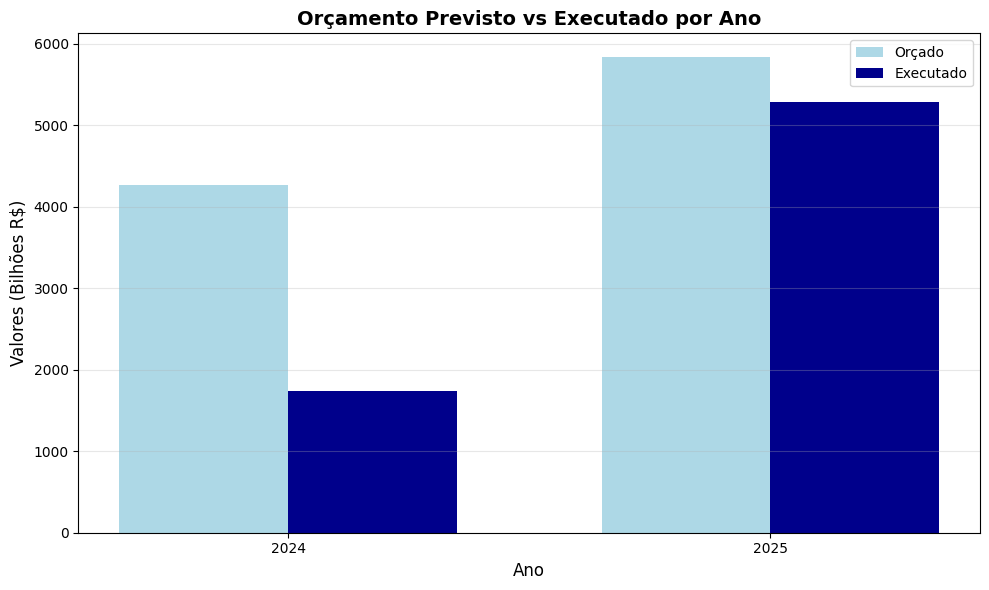


 Gráfico: Em média, 65.7% do orçamento previsto foi executado.


In [0]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# convertendo 
df_orcamento = orcado_vs_executado.toPandas()

# Criar gráfico de barras agrupadas
x = np.arange(len(df_orcamento))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, df_orcamento['orcado_bilhoes'], width, label='Orçado', color='lightblue')
rects2 = ax.bar(x + width/2, df_orcamento['executado_bilhoes'], width, label='Executado', color='darkblue')

ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Valores (Bilhões R$)', fontsize=12)
ax.set_title('Orçamento Previsto vs Executado por Ano', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_orcamento['ID_ANO'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n Gráfico: Em média, {df_orcamento['percentual_executado'].mean():.1f}% do orçamento previsto foi executado.")

In [0]:
%sql --name top_programas
-- Pergunta 5: Quais os top 10 programas que mais receberam recursos?
SELECT 
    NO_PROGRAMA_PT as programa,
    ROUND(SUM(PAGAMENTOS_TOTAIS) / 1000000, 2) as pagamentos_milhoes
FROM gastos_publicos
WHERE NO_PROGRAMA_PT IS NOT NULL AND PAGAMENTOS_TOTAIS IS NOT NULL
GROUP BY NO_PROGRAMA_PT
ORDER BY pagamentos_milhoes DESC
LIMIT 10;

programa,pagamentos_milhoes
OPERACOES ESPECIAIS: REFINANCIAMENTO DA DIVIDA INTERNA,2594286.89
"PREVIDENCIA SOCIAL: PROMOCAO, GARANTIA DE DIREITOS E CIDADAN",1614459.27
OPERACOES ESPECIAIS: SERVICO DA DIVIDA INTERNA (JUROS EAMORT,1243475.53
OPERACOES ESPECIAIS: TRANSFERENCIAS CONSTITUCIONAIS E AS DEC,1134814.85
PROGRAMA DE GESTAO E MANUTENCAO DO PODER EXECUTIVO,703381.14
***********,425584.42
OPERACOES ESPECIAIS: OUTROS ENCARGOS ESPECIAIS,319521.22
BOLSA FAMILIA: PROTECAO SOCIAL POR MEIO DA TRANSFERENCIA DE,271438.10
PROTECAO SOCIAL PELO SISTEMA UNICO DE ASSISTENCIA SOCIAL (SU,198537.25
ATENCAO ESPECIALIZADA A SAUDE,174274.84


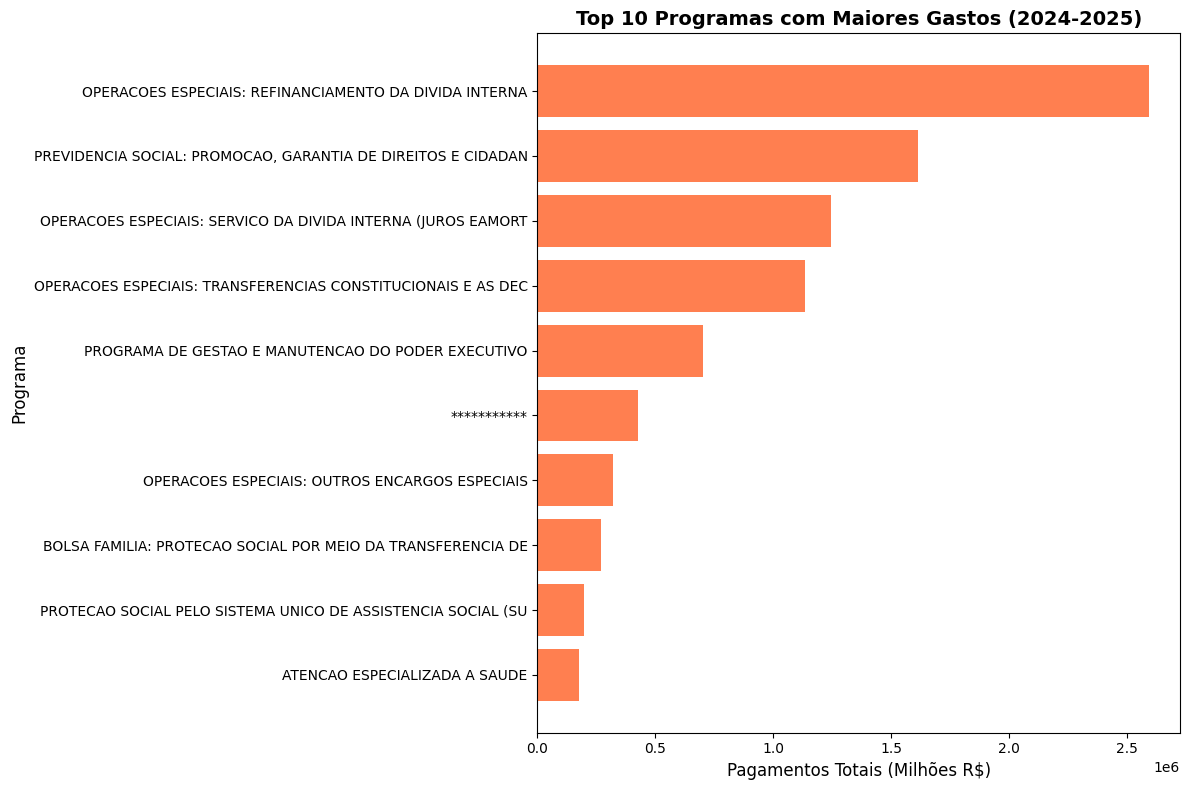


 Gráfico: Programas de Previdência, Saúde e Transferência de Renda concentram os maiores volumes de recursos.


In [0]:
import matplotlib.pyplot as plt
import pandas as pd

# Convertendo 
df_programas = top_programas.toPandas()

# Criar gráfico de barras horizontais
plt.figure(figsize=(12, 8))
plt.barh(df_programas['programa'], df_programas['pagamentos_milhoes'], color='coral')
plt.xlabel('Pagamentos Totais (Milhões R$)', fontsize=12)
plt.ylabel('Programa', fontsize=12)
plt.title('Top 10 Programas com Maiores Gastos (2024-2025)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()

print("\n Gráfico: Programas de Previdência, Saúde e Transferência de Renda concentram os maiores volumes de recursos.")

---
## Conclusões Finais

Após as análises realizadas, podemos concluir:

 **Concentração de gastos**: Poucos órgãos concentram a maior parte do orçamento federal (Previdência, Saúde, Educação).  
 **Sazonalidade**: Os gastos apresentam variações mensais, com picos em determinados períodos.   
 **Execução orçamentária**: Nem todo o orçamento previsto é executado, indicando oportunidades de otimização.  
 **Áreas prioritárias**: Previdência Social, Saúde e Educação são as funções que mais recebem recursos.

